In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import os
import cv2

In [5]:
os.listdir('/kaggle/input/sports-image-classification/dataset')

['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']

In [6]:
img.imread('/kaggle/input/sports-image-classification/dataset/train/00133e413b.jpg').shape

(544, 860, 3)

In [7]:
df_train = pd.read_csv('/kaggle/input/sports-image-classification/dataset/train.csv')

In [8]:
df_train.head()

,image_ID,label
0,7c225f7b61.jpg,Badminton
1,b31.jpg,Badminton
2,acb146546c.jpg,Badminton
3,0e62f4d8f2.jpg,Badminton
4,cfd2c28c74.jpg,Cricket


In [9]:
data = {
    'Cricket':0,
    'Wrestling':1,
    'Tennis':2,
    'Badminton':3,
    'Soccer':4,
    'Swimming':5,
    'Karate':6
}

In [10]:
dict_ = {}
for index,row in df_train.iterrows():
    image_name = row[0]
    label_name = row[1]
    dict_[image_name] = data[label_name]

/tmp/ipykernel_55/395699360.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_name = row[0]
/tmp/ipykernel_55/395699360.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label_name = row[1]


In [11]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

2026-03-27 09:54:30.827036: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774605271.013947      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774605271.065721      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774605271.494120      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774605271.494164      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774605271.494168      55 computation_placer.cc:177] computation placer alr

In [34]:
X_train = []
y_train = []
for i in os.listdir('/kaggle/input/sports-image-classification/dataset/train')[:3000]:
    try:
        image = cv2.imread(f'/kaggle/input/sports-image-classification/dataset/train/{i}')
        image = cv2.resize(image, (224,224))
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = preprocess_input(image)
        X_train.append(image)
        y_train.append(dict_[i])
    except:
        print(i)
X_train = np.array(X_train, dtype='float32')
y_train = np.array(y_train, dtype='float32')

In [35]:
X_train.shape, y_train.shape

((3000, 224, 224, 3), (3000,))

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, GlobalAveragePooling2D, Dense
from keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

In [39]:
from keras.utils import to_categorical

In [40]:
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [41]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [42]:
base_model.trainable=False

In [43]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(7, activation='softmax')
])



In [44]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [45]:
model.fit(X_train,y_train, validation_split=0.15, epochs=15, batch_size=64)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.1793 - loss: 2.1805 - val_accuracy: 0.3139 - val_loss: 1.8469
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.3164 - loss: 1.7760 - val_accuracy: 0.3972 - val_loss: 1.6424
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.4439 - loss: 1.5522 - val_accuracy: 0.5028 - val_loss: 1.4599
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5074 - loss: 1.3987 - val_accuracy: 0.5667 - val_loss: 1.3072
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5960 - loss: 1.2371 - val_accuracy: 0.6278 - val_loss: 1.1880
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6447 - loss: 1.1298 - val_accuracy: 0.6583 - val_loss: 1.0911
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6938 - loss: 1.0092 - val_accuracy: 0.6889 - val_loss: 1.0125
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.7274 - loss: 0.9191 - val_accuracy: 0.7111 - val_loss:

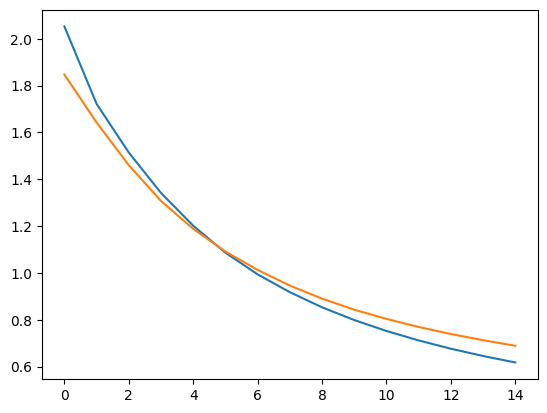

In [46]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])